# Data Preprocessing

## Project
Crop Recommendation System Using Machine Learning with Farmer Expense Tracking

## Module
Crop Recommendation System

## Objective

The objective of this phase is to prepare the dataset before applying machine learning algorithms.

The preprocessing stage ensures that the dataset is:

- Complete
- Consistent
- Free from duplicate records
- Correctly formatted
- Suitable for machine learning

At the end of this notebook, a cleaned dataset will be generated for further analysis and model development.

# Step 1 Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Step 2 Load Dataset

In [5]:
DATA_PATH = Path("../data/Crop_recommendation.csv")

df = pd.read_csv(DATA_PATH)
original_df = df.copy()
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# Step 3 Dataset Shape


In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 2200
Columns : 8


# Step 5 Missing Values

In [7]:
missing_values = df.isnull().sum()

missing_values

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

### Observation

No missing values were found in the dataset.

Therefore, no imputation techniques such as mean, median, or mode replacement are required.

# Step 6 — Duplicate Records

In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Observation
Duplicate records can introduce bias during model training.

Removing duplicate rows ensures better generalization of the machine learning model.

# Step 6 Data Types

In [9]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

#### The dataset contains:

Numerical Features

- Nitrogen
- Phosphorus
- Potassium
- Temperature
- Humidity
- pH
- Rainfall

Categorical Feature

- Crop Label

# Step 7 Check Unique Labels

In [12]:
labels = sorted(df["label"].unique())
print(len(labels))
print(labels)

22
['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


# Step 8 Class Distribution

In [13]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

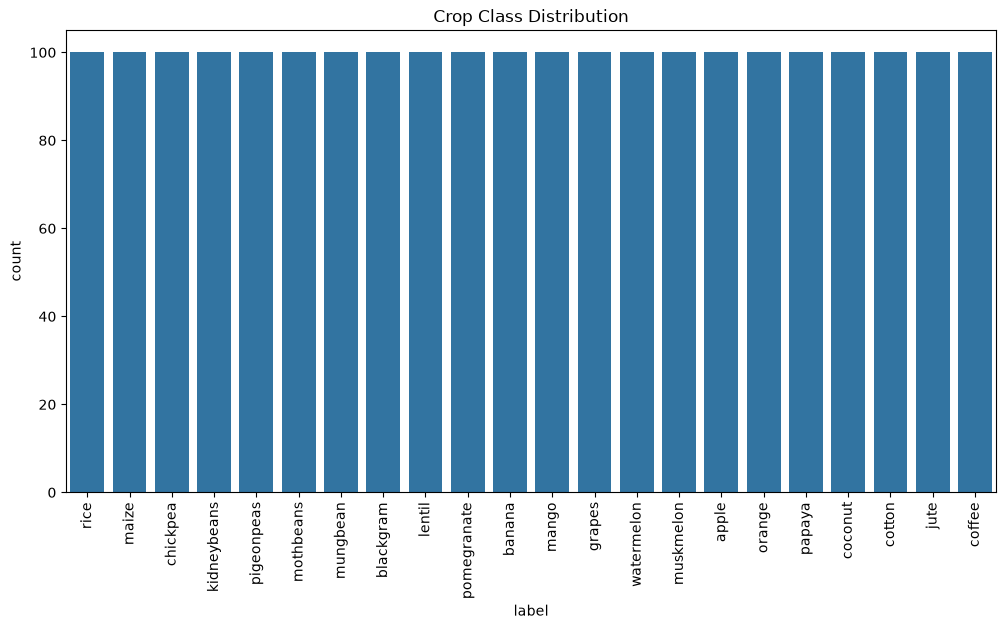

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Crop Class Distribution")

plt.show()

### Purpose

To verify whether the dataset is balanced across all crop classes.

### Observation

Each crop contains equal samples.

### Insight

Balanced datasets reduce the risk of model bias.

### Conclusion

No resampling techniques such as SMOTE or undersampling are required.

In [15]:
#Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [16]:
#Range Validation
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    print(f"{col}")
    print("Minimum :", df[col].min())
    print("Maximum :", df[col].max())
    print("-"*30)

N
Minimum : 0
Maximum : 140
------------------------------
P
Minimum : 5
Maximum : 145
------------------------------
K
Minimum : 5
Maximum : 205
------------------------------
temperature
Minimum : 8.825674745
Maximum : 43.67549305
------------------------------
humidity
Minimum : 14.25803981
Maximum : 99.98187601
------------------------------
ph
Minimum : 3.504752314
Maximum : 9.93509073
------------------------------
rainfall
Minimum : 20.21126747
Maximum : 298.5601175
------------------------------


#### Purpose

Check impossible values like

Negative rainfall

Negative humidity

Negative nitrogen

#### Observation

No invalid numerical values were detected.

All numerical features lie within realistic agricultural ranges.

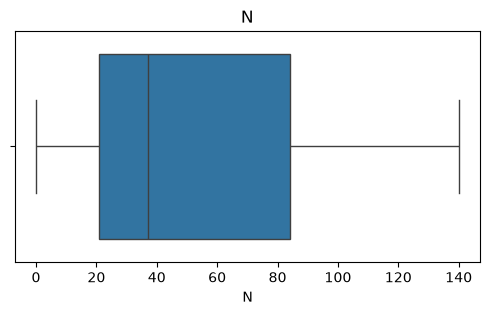

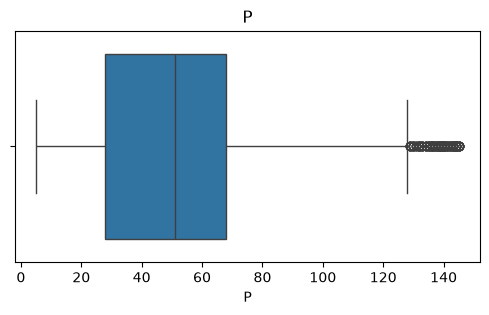

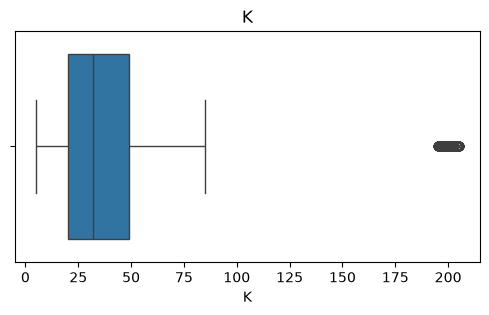

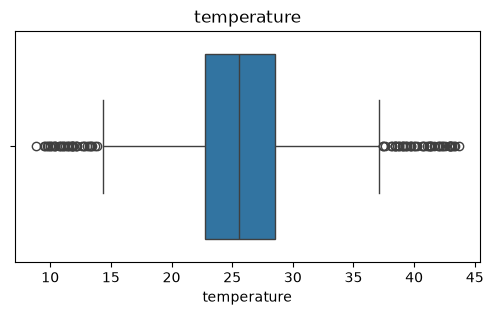

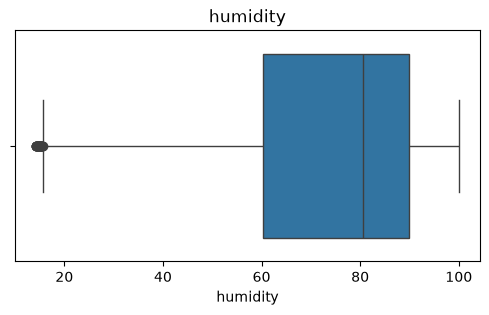

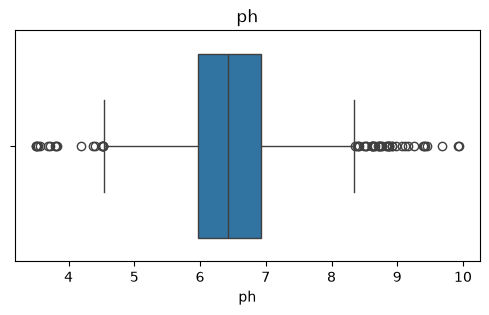

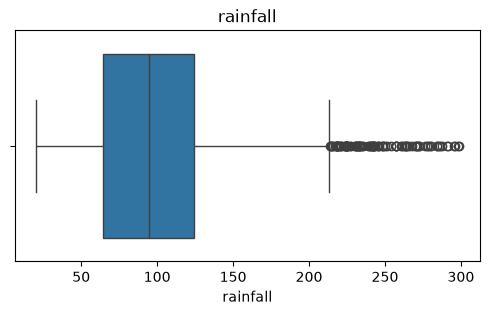

In [19]:
#Check Outliers
for column in numeric_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

### Purpose

To detect extreme observations that may negatively affect model training.

### Observation

Some numerical variables contain mild outliers.

### Insight

Since these values represent natural environmental conditions, they are considered valid observations rather than data errors.

### Conclusion

Outliers will not be removed.

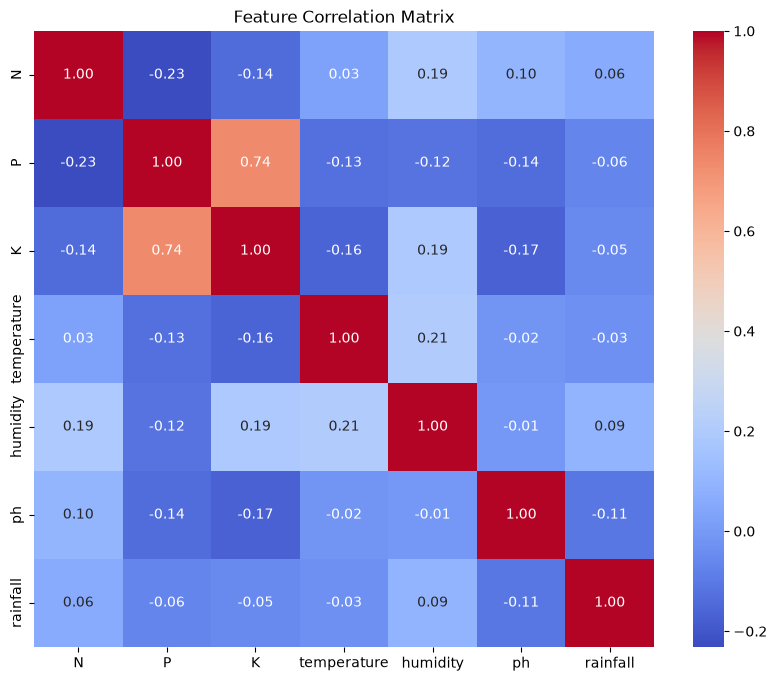

In [20]:
#Correlation Matrix
plt.figure(figsize=(10,8))

corr = df[numeric_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

### Purpose

To identify relationships among numerical features.

### Observation

Most variables exhibit weak to moderate correlations.

### Insight

Low multicollinearity is beneficial for machine learning models.

### Conclusion

All numerical features will be retained.

In [21]:
#Save Clean Dataset
processed_path = Path("../data/processed")

processed_path.mkdir(exist_ok=True)

df.to_csv(
    processed_path/"crop_cleaned.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [27]:
#Final Dataset Check
print(df.head())
print(df.info())
print(df.describe)

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
None
<bound method NDFrame.de